### Download and extract data

In [ ]:
# #!/bin/bash
# !curl -L -o ~/Downloads/utkface-new.zip\
#   https://www.kaggle.com/api/v1/datasets/download/jangedoo/utkface-new

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  331M  100  331M    0     0  3036k      0  0:01:51  0:01:51 --:--:-- 3459k


In [ ]:
# from zipfile import ZipFile

# file = "/home/ree/Downloads/utkface-new.zip"

# with ZipFile(file, "r") as f:
#     f.extractall("data")

### Prepare the data 

In [2]:
import os 
import numpy as np
import pandas as pd

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
# Data Preparation

folder_path = "./data/UTKFace"

image_path = []
age = []
gender = []

for file in os.listdir(folder_path):
    age.append(int(file.split("_")[0]))
    gender.append(int(file.split("_")[1]))
    image_path.append(file)

In [4]:
df = pd.DataFrame({
    "image": image_path,
    "age": age,
    "gender": gender
})

df

,image,age,gender
0,53_1_0_20170120223207284.jpg.chip.jpg,53,1
1,39_0_0_20170104184941845.jpg.chip.jpg,39,0
2,69_1_0_20170110141818223.jpg.chip.jpg,69,1
3,27_1_0_20170117120649662.jpg.chip.jpg,27,1
4,38_1_3_20170105003415085.jpg.chip.jpg,38,1
...,...,...,...
23703,47_1_0_20170117140025374.jpg.chip.jpg,47,1
23704,50_0_0_20170109012530622.jpg.chip.jpg,50,0
23705,45_1_3_20170119183505494.jpg.chip.jpg,45,1
23706,10_0_0_20170110220316298.jpg.chip.jpg,10,0


In [5]:
# Taking only between ages 10 to 60 
# Taking the others are reducing performance. Babies and Old people genders hard to differentiate

df = df[(df["age"] > 10) & (df["age"] < 60)]

In [6]:
# Splitting the df

train_df = df.sample(frac=0.8, random_state=42)
validation_df = df.drop(train_df.index)

train_df.shape, validation_df.shape

((14240, 3), (3560, 3))

In [7]:
validation_df

,image,age,gender
8,32_0_2_20170116162300011.jpg.chip.jpg,32,0
9,18_1_0_20170103175516495.jpg.chip.jpg,18,1
11,14_1_4_20170103201225838.jpg.chip.jpg,14,1
14,26_1_3_20170104232413655.jpg.chip.jpg,26,1
16,25_1_2_20170104020903060.jpg.chip.jpg,25,1
...,...,...,...
23685,35_0_0_20170120134044902.jpg.chip.jpg,35,0
23686,20_0_0_20170116200755014.jpg.chip.jpg,20,0
23688,24_0_2_20170103223924087.jpg.chip.jpg,24,0
23690,30_0_0_20170117151521587.jpg.chip.jpg,30,0


In [21]:
# Create data generators

datagen = ImageDataGenerator(rescale=1/255, validation_split=0.2)        # No augmentation

# Trying out image augmentation. Not so good results without it
# train_datagen = ImageDataGenerator(
#     rescale=1/255,
#     rotation_range=30,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     shear_range=0.2,
#     zoom_range=0.2,
#     horizontal_flip=0.2
# )      

# validation_datagen = ImageDataGenerator(rescale=1/255)

batch_size = 16

train_dataset = datagen.flow_from_dataframe(
    dataframe=df,                       # the dataframe 
    directory=folder_path,              # the directory where data is stored
    x_col="image",                      # the name of column which contains the filenames
    y_col=["age", "gender"],            # the labels 
    class_mode="multi_output",          
    target_size=(128, 128),
    shuffle=True,
    batch_size=batch_size,
    subset="training"                   # only works if validation split is set in DataGenerator
)

validation_dataset = datagen.flow_from_dataframe(
    dataframe=df,                       
    directory=folder_path,              
    x_col="image",                      
    y_col=["age", "gender"],            
    class_mode="multi_output",          
    target_size=(128, 128),
    shuffle=False,                      # We dont need to shuffle validation data
    batch_size=batch_size,
    subset="validation"                 # only works if validation split is set in DataGenerator
)

Found 14240 validated image filenames.
Found 3560 validated image filenames.


### Create the model

In [22]:
# We will be using transfer learning with VGG16

from tensorflow.keras.applications.vgg16 import VGG16

conv_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

# conv_base.trainable = False     # let us try feature extraction first

# Trying out fine tuning
set_trainable = False
for layer in conv_base.layers:
    if layer.name == "block5_conv3":        # unfreeze from block 5 conv 3 onwards
        set_trainable = True 
    layer.trainable = set_trainable
    
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 2,359,808 (9.00 MB)

 Non-trainable params: 12,354,880 (47.13 MB)

In [23]:
# Building the model

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten 

In [24]:
# Defining the layers and connections

flatten = Flatten()(conv_base.output)

dense_age_1 = Dense(units=512, activation="relu")(flatten)
dense_age_2 = Dense(units=512, activation="relu")(dense_age_1)
output_age = Dense(units=1, activation="linear", name="age")(dense_age_2)       
# set the name in output layers so model.compile() knows the which metric to track when we provide a dictionary

dense_gender_1 = Dense(units=512, activation="relu")(flatten)            
dense_gender_2 = Dense(units=512, activation="relu")(dense_gender_1)
output_gender = Dense(units=1, activation="sigmoid", name="gender")(dense_gender_2)
# set the name in output layers so model.compile() knows the which metric to track when we provide a dictionary

In [25]:
# create the model

model = Model(
    inputs=conv_base.input,
    outputs=[output_age, output_gender]
)

In [26]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 128, 128,  │      1,792 │ input_layer_2[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 128, 128,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 64, 64,    │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 64, 64,    │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 64, 64,    │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 32, 32,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 32, 32,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 32, 32,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 32, 32,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 16, 16,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 16, 16,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 16, 16,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 16, 16,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 8, 8, 512) │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 8, 8, 512) │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 8, 8, 512) │  2,359,808 │ block5_conv1[0][

 Total params: 23,630,658 (90.14 MB)

 Trainable params: 11,275,778 (43.01 MB)

 Non-trainable params: 12,354,880 (47.13 MB)

In [27]:
from tensorflow.keras.utils import plot_model

# plot_model(model=model, show_layer_activations=True, show_shapes=True, show_trainable=True)

### Model training and evaluation

In [30]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1),
    loss={"age": "mse", "gender": "binary_crossentropy"},
    metrics={"age": "r2_score", "gender": "accuracy"},
)

ValueError: Argument `learning_rate` should be float, or an instance of LearningRateSchedule, or a callable (that takes in the current iteration value and returns the corresponding learning rate value). Received instead: learning_rate=1

In [31]:
def convert_generator(gen):        
    for x, y in gen:
        yield x, tuple(y)
train_dataset = convert_generator(train_dataset)
validation_dataset = convert_generator(validation_dataset)

# no idea what its doing but fixed the error - Chatgpt says: 

# I wrapped the generator’s output to convert the labels from a list into a tuple. 
# TensorFlow expects the output signature (i.e. the format of the labels) to be a tuple or a dictionary of
# TensorFlow TypeSpecs—not a list. By converting the list [age, gender] to a tuple (age, gender), 
# the model receives the data in the correct format, resolving the error.

augmentation_factor = 1     # to generate more than one augmented images 
steps_per_epoch = (18967 // batch_size) * augmentation_factor
validation_steps = (4741 // batch_size) * augmentation_factor

history = model.fit(
    x=train_dataset,
    epochs=10,
    validation_data=validation_dataset,
    steps_per_epoch=steps_per_epoch,            # check this also why needed (training was not stopping otherwise)
    validation_steps=validation_steps           # this also
)

Epoch 1/10
1185/1185 ━━━━━━━━━━━━━━━━━━━━ 100s 85ms/step - age_loss: 1410.2480 - age_r2_score: -10.3521 - gender_accuracy: 0.5143 - gender_loss: 0.9318 - loss: 1411.1801 - val_age_loss: 560.7556 - val_age_r2_score: -3.4814 - val_gender_accuracy: 0.5114 - val_gender_loss: 0.6929 - val_loss: 562.1454
Epoch 2/10
1185/1185 ━━━━━━━━━━━━━━━━━━━━ 100s 84ms/step - age_loss: 2464.1738 - age_r2_score: -18.5443 - gender_accuracy: 0.5185 - gender_loss: 0.6949 - loss: 2464.8682 - val_age_loss: 352.7565 - val_age_r2_score: -1.8117 - val_gender_accuracy: 0.5184 - val_gender_loss: 0.6925 - val_loss: 353.8292
Epoch 3/10
1185/1185 ━━━━━━━━━━━━━━━━━━━━ 102s 86ms/step - age_loss: 219.2934 - age_r2_score: -0.7265 - gender_accuracy: 0.5071 - gender_loss: 0.6959 - loss: 219.9893 - val_age_loss: 136.3767 - val_age_r2_score: -0.1171 - val_gender_accuracy: 0.4816 - val_gender_loss: 0.6932 - val_loss: 137.0652
Epoch 4/10
1185/1185 ━━━━━━━━━━━━━━━━━━━━ 100s 84ms/step - age_loss: 151.2140 - age_r2_score: -0.2138 -

KeyboardInterrupt: 

<Axes: >

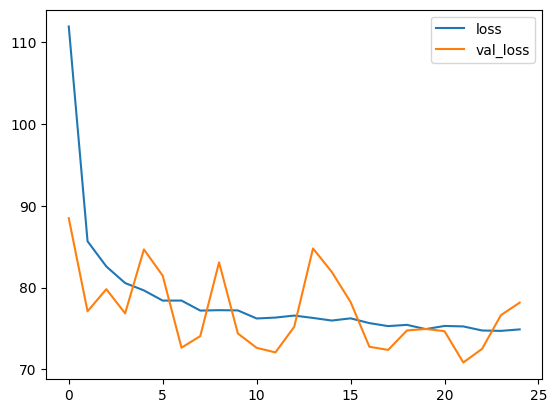

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(history.history["loss"], label="loss")
sns.lineplot(history.history["val_loss"], label="val_loss")

<Axes: >

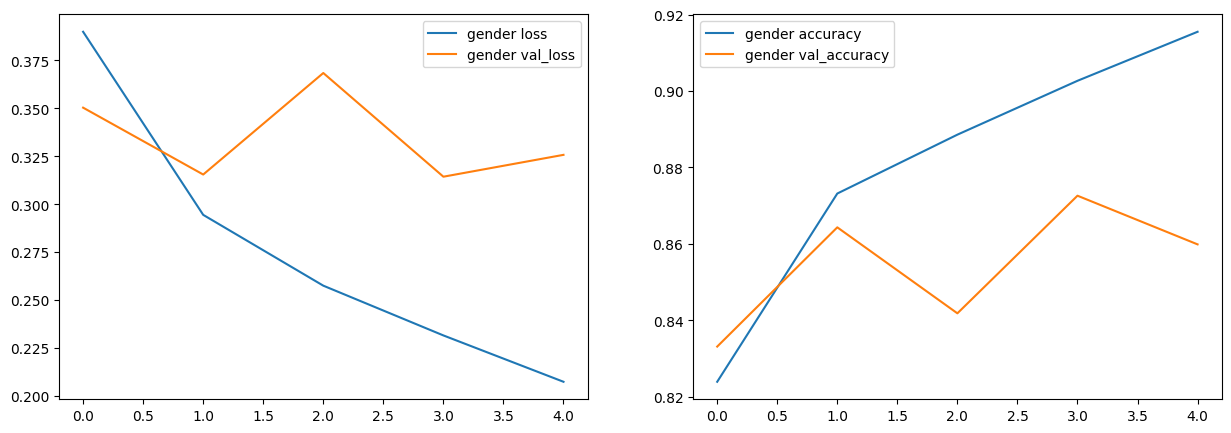

In [48]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))

sns.lineplot(history.history["gender_loss"], label="gender loss", ax=ax[0])
sns.lineplot(history.history["val_gender_loss"], label="gender val_loss", ax=ax[0])

sns.lineplot(history.history["gender_accuracy"], label="gender accuracy", ax=ax[1])
sns.lineplot(history.history["val_gender_accuracy"], label="gender val_accuracy", ax=ax[1])

<Axes: >

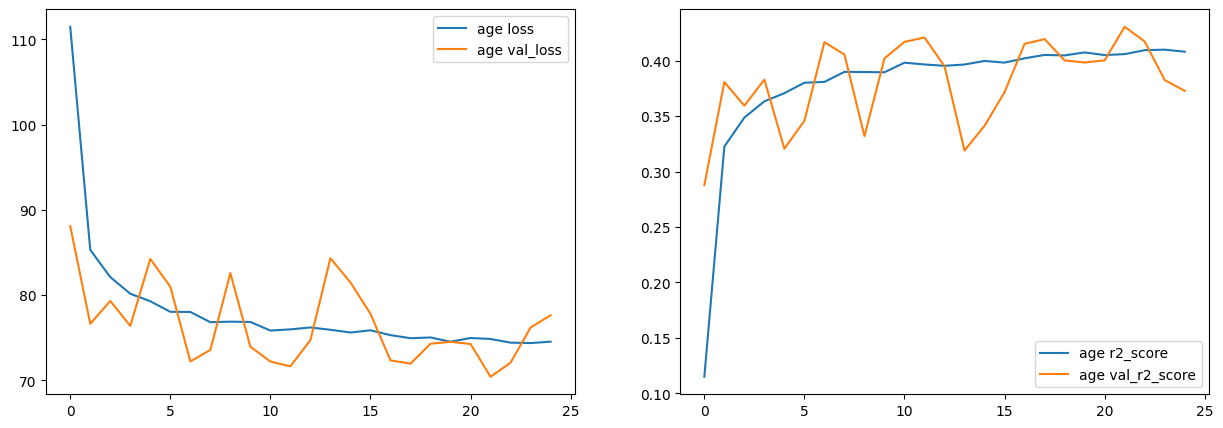

In [30]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))

sns.lineplot(history.history["age_loss"], label="age loss", ax=ax[0])
sns.lineplot(history.history["val_age_loss"], label="age val_loss", ax=ax[0])

sns.lineplot(history.history["age_r2_score"], label="age r2_score", ax=ax[1])
sns.lineplot(history.history["val_age_r2_score"], label="age val_r2_score", ax=ax[1])

In [ ]:
# Seems like its working pretty well
# Good r2 score and accuracy, not much overfitting

In [ ]:
# Saving the model 

# model.save("my_model.keras")

### Using opencv to detect my own face
Check the app.py

In [34]:
import tensorflow as tf

model = tf.keras.models.load_model("my_model.keras")

In [36]:
import cv2

# Open the default camera
cam = cv2.VideoCapture(0)

# Set the frame width and height and frame limit
cam.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)  
cam.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)  
cam.set(cv2.CAP_PROP_FPS, 25)

while True:
    ret, frame = cam.read()

    # make predictions 
    try:
        img = cv2.resize(frame, (128, 128))
        img = img.reshape(1, 128, 128, 3)       # converting to batch for prediction
        y_pred = model.predict(img)
        age = round(y_pred[0][0][0], 0)
        gender = y_pred[1][0][0]
        gender = "Male" if gender==1 else "Female"
    except Exception as e:
        print(e)
    
    
    font = cv2.FONT_HERSHEY_SIMPLEX 
    cv2.putText(frame, f"Age: {str(age)}", (50, 50), font, 1, (0, 255, 255), 2, cv2.LINE_4) 
    cv2.putText(frame, f"Gender: {str(gender)}", (50, 100), font, 1, (0, 255, 0), 2, cv2.LINE_4) 

    # Display the captured frame
    cv2.imshow('Camera', frame)
    
    # Press 'q' to exit the loop
    if cv2.waitKey(1) == ord('q'):
        break

# Release the capture and writer objects
cam.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━